In [20]:
"""
Dry compaction module (HS2SWE vs ΔSNOW) — minimal + structured

What this script does (once, in a sensible order):
1) Defines both single-layer compaction step functions.
2) Runs a small experiment for multiple overburden stress levels and TWO initial densities.
3) Produces ONE figure:
   - 2x4 panel grid (Light + Dense) with HS, rho, SWE, settling rate S=σ/η
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec


# ============================================================
# USER SETTINGS (edit here)
# ============================================================
DT_S = 86400.0
N_DAYS = 60
T_DAYS = np.arange(N_DAYS)

G = 9.81

# stress levels (Pa = N/m^2)
SIGMA_LEVELS = np.array([10.0, 100.0, 1000, 4000.0], dtype=float)

# imposed overburden mass [kg m^-2], so sigma = ovb*g  <=> ovb = sigma/g
OVB_SWE = SIGMA_LEVELS / G


# Initial conditions
HS0_CM = 50.0
SNOTEMP = 0.0

# Only two configs as requested
RHO0_CONFIGS = {
    "Light snow": 120.56,
    "Dense snow": 250.0,
}

# Settling-rate viscosity laws (same as used elsewhere in your notebook)
ETA0_DS, K_DS = 8.5e6, 0.030
VISC_HS, C5_HS = 6.051e7, 0.018


# ============================================================
# Globals to store the last computed HS2SWE terms
# ============================================================
HS2SWE_TERM_OVB = np.nan
HS2SWE_TERM_METAMORPH = np.nan



In [21]:
# ============================================================
# HS2SWE step
# ============================================================
def hs2swe_single_layer_step(
    hs_cm,
    rho,
    ovb_kg_m2,
    SnoTemp=0.0,
    dt_s=86400.0,
    g=9.81,
    rho_new=113.7,
    rho_max=571.6,
    visc=6.051e7,
    c1=2.8e-6,
    c2=0.042,
    c3=0.046,
    c4=0.081,
    c5=0.018,
):
    """
    HS2SWE: One dry-compaction step for a single homogeneous layer under imposed overburden.
    SWE is conserved (hs adjusts to density change).

    Side effect
    ----------
    Updates global variables:
        HS2SWE_TERM_OVB       : overburden compaction term [s^-1]
        HS2SWE_TERM_METAMORPH : metamorphism term         [s^-1]
    """
    global HS2SWE_TERM_OVB, HS2SWE_TERM_METAMORPH

    rho_safe = max(float(rho), 1e-9)

    term_overburden = (ovb_kg_m2 * g) / (visc * np.exp(c4 * SnoTemp + c5 * rho_safe))
    term_metamorph = c1 * np.exp(-c2 * SnoTemp - c3 * max(0.0, rho_safe - rho_new))

    HS2SWE_TERM_OVB = term_overburden
    HS2SWE_TERM_METAMORPH = term_metamorph

    rho_new_val = rho_safe + rho_safe * dt_s * (term_overburden + term_metamorph)
    rho_new_val = min(rho_new_val, rho_max)

    hs_cm_new = hs_cm / (rho_new_val / rho_safe)
    return hs_cm_new, rho_new_val


# ============================================================
# ΔSNOW step
# ============================================================
def dsnow_single_layer_step(
    hs_cm,
    rho,
    ovb_kg_m2,
    dt_s=86400.0,
    g=9.81,
    eta0_Pa_s=8.5e6,
    k_m3_kg=0.030,
    rho_max=401.0,
):
    """
    ΔSNOW: One dry-compaction step for a single homogeneous layer under imposed overburden.
    SWE is conserved.
    """
    swe = hs_cm * rho / 100.0  # [kg m^-2]
    hs_m = max(hs_cm / 100.0, 1e-9)
    rho_safe = swe / hs_m

    b_sigma = g * (ovb_kg_m2 + swe)  # [Pa]
    eta = eta0_Pa_s * np.exp(k_m3_kg * rho_safe)

    comp_factor = 1.0 + dt_s * (b_sigma / eta)
    hs_m_new = hs_m / comp_factor

    hs_m_new = max(hs_m_new, swe / rho_max)
    rho_new = swe / max(hs_m_new, 1e-9)

    return hs_m_new * 100.0, rho_new

In [22]:
# ============================================================
# Styling
# ============================================================
def set_pub_style():
    plt.style.use("seaborn-v0_8-whitegrid")
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
        "lines.linewidth": 2.2,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
    })


# ============================================================
# Experiment runner
# ============================================================
def run_experiment(
    sigma_levels,
    ovb_swe,
    rho0_configs,
    hs0_cm,
    SnoTemp,
    dt_s,
    n_days,
    g,
):
    n_sigma = len(sigma_levels)
    results = {}

    for name, rho0 in rho0_configs.items():
        HS_hs2 = np.zeros((n_sigma, n_days))
        RHO_hs2 = np.zeros((n_sigma, n_days))
        HS_ds = np.zeros((n_sigma, n_days))
        RHO_ds = np.zeros((n_sigma, n_days))

        HS_hs2[:, 0] = hs0_cm
        RHO_hs2[:, 0] = rho0
        HS_ds[:, 0] = hs0_cm
        RHO_ds[:, 0] = rho0

        for j in range(n_sigma):
            for i in range(1, n_days):
                HS_hs2[j, i], RHO_hs2[j, i] = hs2swe_single_layer_step(
                    HS_hs2[j, i - 1],
                    RHO_hs2[j, i - 1],
                    ovb_swe[j],
                    SnoTemp=SnoTemp,
                    dt_s=dt_s,
                    g=g,
                )
                HS_ds[j, i], RHO_ds[j, i] = dsnow_single_layer_step(
                    HS_ds[j, i - 1],
                    RHO_ds[j, i - 1],
                    ovb_swe[j],
                    dt_s=dt_s,
                    g=g,
                )

        SWE_hs2 = (HS_hs2 / 100.0) * RHO_hs2
        SWE_ds = (HS_ds / 100.0) * RHO_ds

        results[name] = {
            "rho0": rho0,
            "HS_hs2": HS_hs2, "RHO_hs2": RHO_hs2, "SWE_hs2": SWE_hs2,
            "HS_ds": HS_ds,   "RHO_ds": RHO_ds,   "SWE_ds": SWE_ds,
        }

    return results

In [23]:
# ============================================================
# PLOTTING ONLY (2x4 time grid + 3D surfaces)
# Call these from your main() after you computed `results`.
# Assumes globals exist: ETA0_DS, K_DS, VISC_HS, C5_HS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm
import matplotlib.gridspec as gridspec


def plot_evolution_grid_2x4(
    results,
    t_days,
    sigma_levels,
    colors_sigma,
    outfile="snowpack_evolution_2x4.png",
):
    """
    Rows = configs (e.g., Light, Dense)
    Cols = HS | rho | SWE | settling S=σ/η
    HS2SWE solid, ΔSNOW dashed.

    `results[name]` must contain:
      HS_hs2, RHO_hs2, SWE_hs2, HS_ds, RHO_ds, SWE_ds, rho0
      with arrays shaped (n_sigma, n_days)
    """
    n_cfg = len(results)
    n_sigma = len(sigma_levels)

    fig = plt.figure(figsize=(18, 3.7 * n_cfg), constrained_layout=False)
    fig.suptitle("Snowpack Evolution: HS2SWE vs ΔSNOW (HS, ρ, SWE, σ/η)",
                 fontsize=16, y=0.995)
    gs = gridspec.GridSpec(n_cfg, 4, figure=fig, hspace=0.35, wspace=0.28)

    for idx, (cfg_name, data) in enumerate(results.items()):
        # ---- Col 1: HS ----
        ax1 = fig.add_subplot(gs[idx, 0])
        for j in range(n_sigma):
            ax1.plot(t_days, data["HS_hs2"][j], color=colors_sigma[j], ls="-",  alpha=0.95)
            ax1.plot(t_days, data["HS_ds"][j],  color=colors_sigma[j], ls="--", alpha=0.95)
        ax1.set_xlabel("Time [days]")
        ax1.set_ylabel("HS [cm]")
        ax1.set_title(f"{cfg_name}\n($\\rho_0$={data['rho0']:.0f} kg m$^{{-3}}$)", fontsize=11)

        # ---- Col 2: rho ----
        ax2 = fig.add_subplot(gs[idx, 1])
        for j in range(n_sigma):
            ax2.plot(t_days, data["RHO_hs2"][j], color=colors_sigma[j], ls="-",  alpha=0.95)
            ax2.plot(t_days, data["RHO_ds"][j],  color=colors_sigma[j], ls="--", alpha=0.95)
        ax2.set_xlabel("Time [days]")
        ax2.set_ylabel(r"Density $\rho$ [kg m$^{-3}$]")
        ax2.set_title("Density", fontsize=11)

        # ---- Col 3: SWE ----
        ax3 = fig.add_subplot(gs[idx, 2])
        for j in range(n_sigma):
            ax3.plot(t_days, data["SWE_hs2"][j], color=colors_sigma[j], ls="-",  alpha=0.95)
            ax3.plot(t_days, data["SWE_ds"][j],  color=colors_sigma[j], ls="--", alpha=0.95)
        ax3.set_xlabel("Time [days]")
        ax3.set_ylabel(r"SWE [kg m$^{-2}$]")
        ax3.set_title("SWE", fontsize=11)

        # ---- Col 4: Settling rate S = σ/η ----
        ax4 = fig.add_subplot(gs[idx, 3])

        # viscosity from current densities (vectorized)
        eta_ds_t = ETA0_DS * np.exp(K_DS * data["RHO_ds"])
        eta_hs_t = VISC_HS * np.exp(C5_HS * data["RHO_hs2"])

        sigma_col = sigma_levels[:, None]  # (n_sigma, 1)
        S_ds_t = sigma_col / eta_ds_t
        S_hs_t = sigma_col / eta_hs_t

        for j in range(n_sigma):
            ax4.plot(t_days, S_hs_t[j], color=colors_sigma[j], ls="-",  alpha=0.95)
            ax4.plot(t_days, S_ds_t[j], color=colors_sigma[j], ls="--", alpha=0.95)

        ax4.set_yscale("log")
        ax4.set_xlabel("Time [days]")
        ax4.set_ylabel(r"Settling rate $S=\sigma/\eta$ [s$^{-1}$]")
        ax4.set_title("Settling rate", fontsize=11)

    # ---- Legend (sigma colors + model linestyle) ----
    legend_sigma = [
        Line2D([0], [0], color=colors_sigma[j], lw=2, label=rf"$\sigma={sigma_levels[j]:.0f}$ Pa")
        for j in range(n_sigma)
    ]
    legend_model = [
        Line2D([0], [0], color="0.25", lw=2, ls="-",  label="HS2SWE"),
        Line2D([0], [0], color="0.25", lw=2, ls="--", label=r"$\Delta$SNOW"),
    ]
    fig.legend(handles=legend_sigma + legend_model,
               loc="lower center", bbox_to_anchor=(0.5, 0.01),
               ncol=min(7, n_sigma + 2), frameon=True, fancybox=True)

    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()


def plot_settling_surfaces_3d(
    rho_min=81.0,
    rho_max=401.0,
    sigma_min=10.0,
    sigma_max=1000.0,
    n_rho=220,
    n_sigma=140,
    elev=15,
    azim=30,
    plane_alpha=0.28,
    plane_color="0.45",
    plane_z_eps=1e-12,
    outfile=None,
):
    """
    3D surfaces based only on viscosity laws:
      S_DS = σ / η_DS,  η_DS = ETA0_DS * exp(K_DS * ρ)
      S_HS = σ / η_HS,  η_HS = VISC_HS * exp(C5_HS * ρ)

    Plots 2x2:
      (1) S_DS
      (2) S_HS
      (3) ΔS centered at 0 (diverging cmap + reference plane at 0)
      (4) ratio centered at 1 (diverging cmap + reference plane at 1)
    """
    rho = np.linspace(rho_min, rho_max, n_rho)
    sigma = np.logspace(np.log10(sigma_min), np.log10(sigma_max), n_sigma)
    RHO, SIG = np.meshgrid(rho, sigma)

    ETA_DS_GRID = ETA0_DS * np.exp(K_DS * RHO)
    ETA_HS_GRID = VISC_HS * np.exp(C5_HS * RHO)

    S_DS = SIG / ETA_DS_GRID
    S_HS = SIG / ETA_HS_GRID
    DELTA_S = S_DS - S_HS
    RATIO_S = S_DS / S_HS

    # centered norms
    absmax_diff = float(np.nanmax(np.abs(DELTA_S)))
    norm_diff = TwoSlopeNorm(vmin=-absmax_diff, vcenter=0.0, vmax=absmax_diff)

    absmax_ratio = float(np.nanmax(np.abs(RATIO_S - 1.0)))
    norm_ratio = TwoSlopeNorm(vmin=1.0 - absmax_ratio, vcenter=1.0, vmax=1.0 + absmax_ratio)

    def _style_3d(ax, az=None):
        ax.view_init(elev=elev, azim=azim if az is None else az)
        ax.set_xlim(rho.min(), rho.max())
        ax.set_ylim(sigma.min(), sigma.max())
        # keep “min-min corner together” look
        ax.invert_xaxis()
        ax.invert_yaxis()
        ax.xaxis.pane.set_alpha(0.05)
        ax.yaxis.pane.set_alpha(0.05)
        ax.zaxis.pane.set_alpha(0.05)
        ax.grid(True, alpha=0.22)

    def _add_plane(ax, level):
        ax.plot_surface(
            RHO, SIG, (level - plane_z_eps) * np.ones_like(RHO),
            color=plane_color, alpha=plane_alpha,
            edgecolor="none", shade=False, zorder=0
        )

    fig = plt.figure(figsize=(13, 10), constrained_layout=True)

    # 1) S_DS
    ax1 = fig.add_subplot(2, 2, 1, projection="3d")
    surf1 = ax1.plot_surface(RHO, SIG, S_DS, cmap="cividis",
                             edgecolor="none", antialiased=True, alpha=0.97)
    _style_3d(ax1, az=60)
    ax1.set_title(r"$\Delta$SNOW settling rate $S=\sigma/\eta$")
    ax1.set_xlabel(r"Density $\rho$ [kg m$^{-3}$]")
    ax1.set_ylabel(r"Overburden stress $\sigma$ [Pa]")
    ax1.set_zlabel(r"$S\ [s^{-1}]$")
    cb1 = fig.colorbar(surf1, ax=ax1, shrink=0.75, pad=0.08)
    cb1.set_label(r"$S\ [s^{-1}]$")

    # 2) S_HS
    ax2 = fig.add_subplot(2, 2, 2, projection="3d")
    surf2 = ax2.plot_surface(RHO, SIG, S_HS, cmap="viridis",
                             edgecolor="none", antialiased=True, alpha=0.97)
    _style_3d(ax2, az=60)
    ax2.set_title(r"HS2SWE settling rate $S=\sigma/\eta$")
    ax2.set_xlabel(r"Density $\rho$ [kg m$^{-3}$]")
    ax2.set_ylabel(r"Overburden stress $\sigma$ [Pa]")
    ax2.set_zlabel(r"$S\ [s^{-1}]$")
    cb2 = fig.colorbar(surf2, ax=ax2, shrink=0.75, pad=0.08)
    cb2.set_label(r"$S\ [s^{-1}]$")

    # 3) ΔS centered at 0
    ax3 = fig.add_subplot(2, 2, 3, projection="3d")
    _style_3d(ax3)
    _add_plane(ax3, level=0.0)
    surf3 = ax3.plot_surface(RHO, SIG, DELTA_S, cmap="RdBu_r", norm=norm_diff,
                             edgecolor="none", antialiased=True, alpha=0.97, zorder=10)
    ax3.set_title(r"Difference $\Delta S = S_{\Delta SNOW} - S_{HS2SWE}$")
    ax3.set_xlabel(r"Density $\rho$ [kg m$^{-3}$]")
    ax3.set_ylabel(r"Overburden stress $\sigma$ [Pa]")
    ax3.set_zlabel(r"$\Delta S\ [s^{-1}]$")
    cb3 = fig.colorbar(surf3, ax=ax3, shrink=0.75, pad=0.08)
    cb3.set_label(r"$\Delta S\ [s^{-1}]$")

    # 4) Ratio centered at 1
    ax4 = fig.add_subplot(2, 2, 4, projection="3d")
    _style_3d(ax4, az=100)
    _add_plane(ax4, level=1.0)
    surf4 = ax4.plot_surface(RHO, SIG, RATIO_S, cmap="RdBu_r", norm=norm_ratio,
                             edgecolor="none", antialiased=True, alpha=0.97, zorder=10)
    ax4.set_title(r"Ratio $S_{\Delta SNOW} / S_{HS2SWE}$")
    ax4.set_xlabel(r"Density $\rho$ [kg m$^{-3}$]")
    ax4.set_ylabel(r"Overburden stress $\sigma$ [Pa]")
    ax4.set_zlabel("Ratio [-]")
    cb4 = fig.colorbar(surf4, ax=ax4, shrink=0.75, pad=0.08)
    cb4.set_label("Ratio [-]")

    if outfile:
        plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()



# ============================================================
# 1D LINE PLOT: Effective viscosity η(ρ)
# ============================================================
# Uses global viscosity laws:
#   ΔSNOW : η = ETA0_DS * exp(K_DS * ρ)
#   HS2SWE: η = VISC_HS * exp(C5_HS * ρ)

import numpy as np
import matplotlib.pyplot as plt


def plot_effective_viscosity_line(
    rho_min=81.0,
    rho_max=401.0,
    n_rho=600,
    logscale=True,
    outfile="effective_viscosity.png",
):
    """
    Plots effective viscosity vs density for both models.

    Parameters
    ----------
    rho_min, rho_max : float
        Density range [kg m^-3]
    n_rho : int
        Resolution of density grid
    logscale : bool
        If True → log-scale on y-axis (recommended)
    """

    rho = np.linspace(rho_min, rho_max, n_rho)

    eta_ds = ETA0_DS * np.exp(K_DS * rho)
    eta_hs = VISC_HS * np.exp(C5_HS * rho)

    delta_eta = eta_ds - eta_hs
    ratio_eta = eta_ds / eta_hs

    fig, axes = plt.subplots(3, 1, figsize=(8.5, 10), constrained_layout=True)

    # --------------------------------------------------------
    # (1) Absolute viscosity
    # --------------------------------------------------------
    axes[0].plot(rho, eta_ds, label="ΔSNOW", color="tab:blue")
    axes[0].plot(rho, eta_hs, label="HS2SWE", color="tab:orange")
    if logscale:
        axes[0].set_yscale("log")
    axes[0].set_ylabel("Viscosity η [Pa s]")
    axes[0].set_title("Effective viscosity vs density")
    axes[0].legend()

    # --------------------------------------------------------
    # (2) Absolute difference
    # --------------------------------------------------------
    axes[1].plot(rho, delta_eta, color="tab:green")
    axes[1].axhline(0.0, color="black", linewidth=1, alpha=0.5)
    axes[1].set_ylabel("Δη [Pa s]")
    axes[1].set_title("Viscosity difference (ΔSNOW − HS2SWE)")

    # --------------------------------------------------------
    # (3) Ratio
    # --------------------------------------------------------
    axes[2].plot(rho, ratio_eta, color="tab:red")
    axes[2].axhline(1.0, color="black", linewidth=1, alpha=0.5)
    axes[2].set_xlabel("Density ρ [kg m$^{-3}$]")
    axes[2].set_ylabel("η_ΔSNOW / η_HS2SWE")
    axes[2].set_title("Viscosity ratio")

    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()




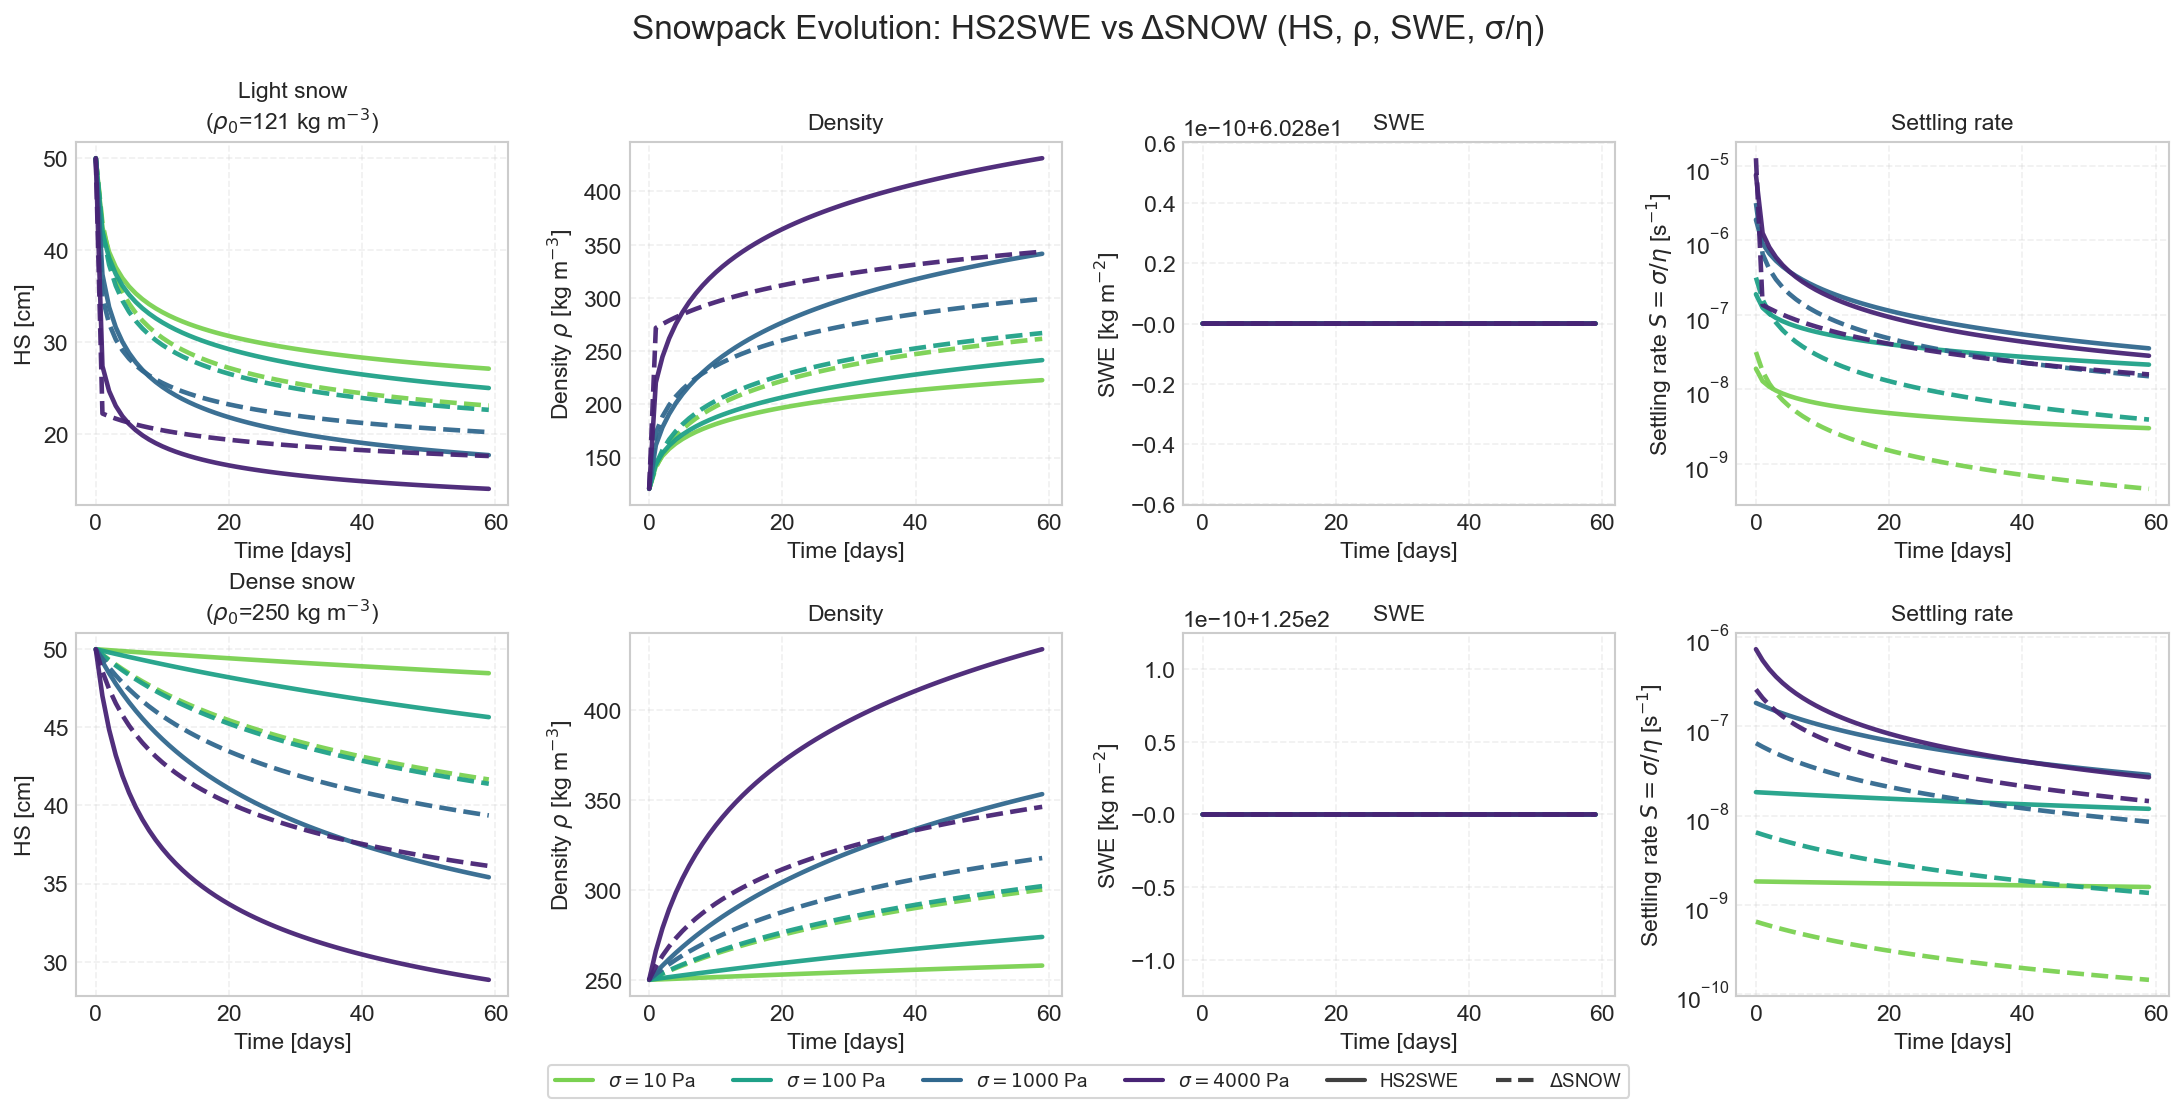

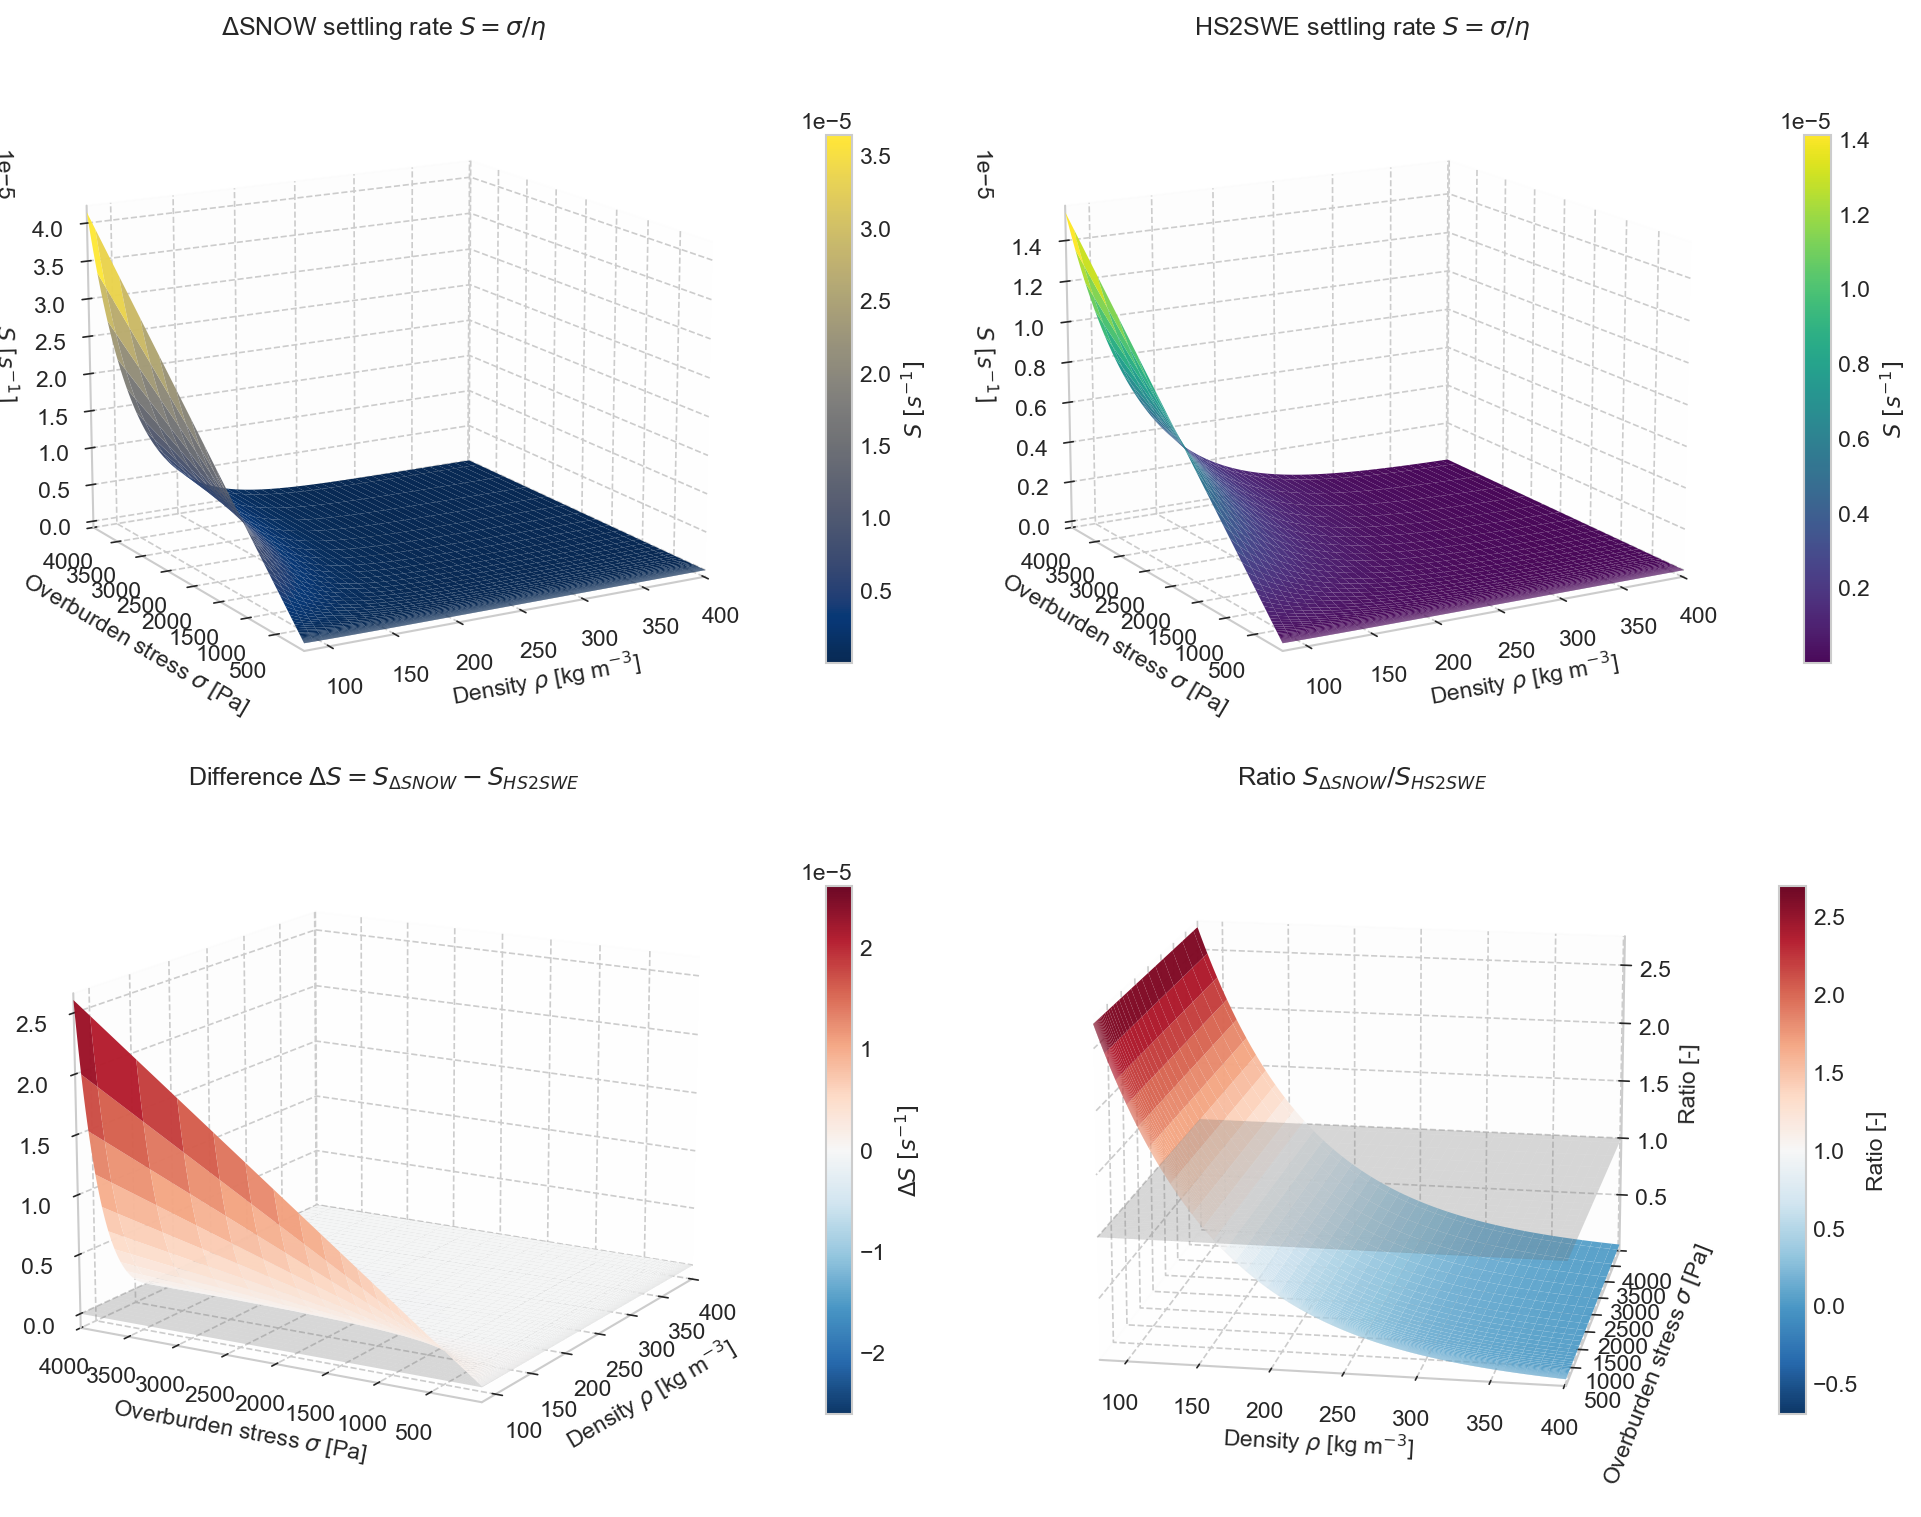

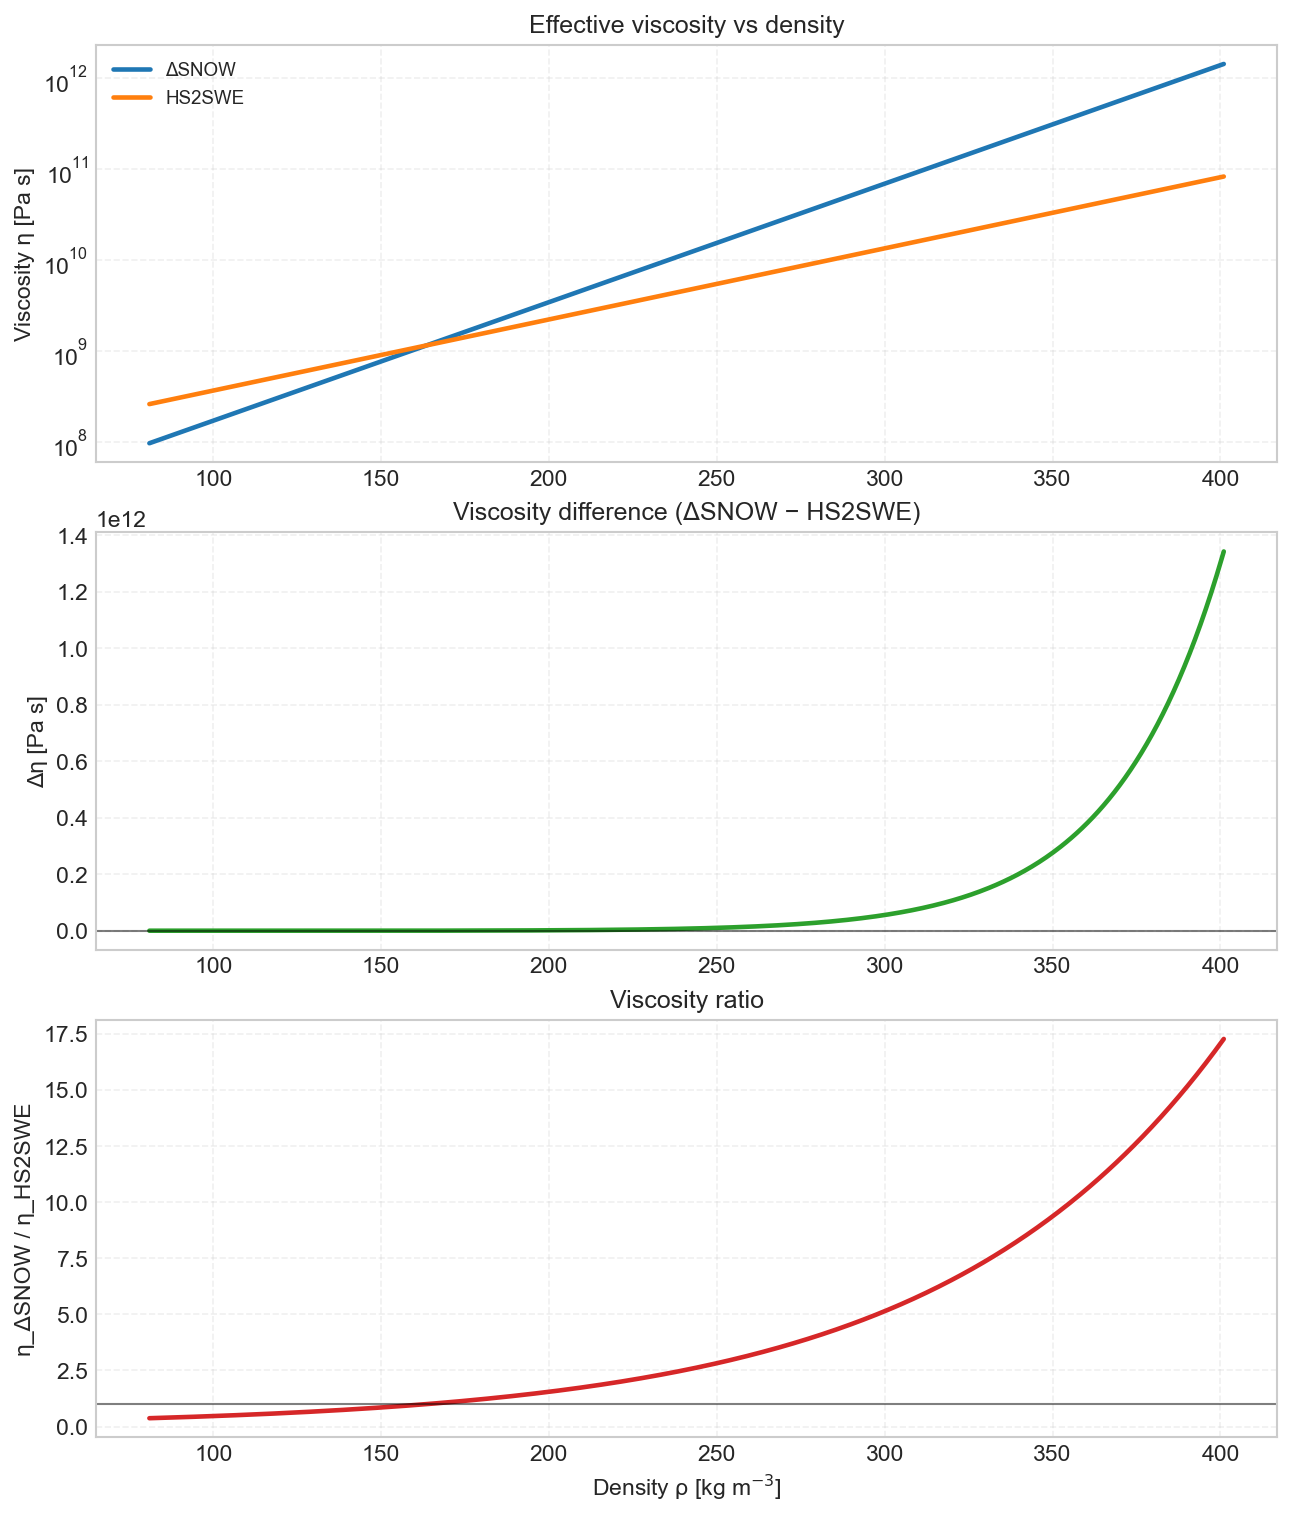

In [24]:
# ============================================================
# MAIN (run once)
# ============================================================
def main():
    set_pub_style()

    n_sigma = len(SIGMA_LEVELS)
    colors_sigma = plt.cm.viridis_r(np.linspace(0.2, 0.9, n_sigma))

    results = run_experiment(
        sigma_levels=SIGMA_LEVELS,
        ovb_swe=OVB_SWE,
        rho0_configs=RHO0_CONFIGS,
        hs0_cm=HS0_CM,
        SnoTemp=SNOTEMP,
        dt_s=DT_S,
        n_days=N_DAYS,
        g=G,
    )

    # 2 configs => 2x4 panel grid

    plot_evolution_grid_2x4(results, T_DAYS, SIGMA_LEVELS, colors_sigma)
    plot_settling_surfaces_3d(
    rho_min=81.0, rho_max=401.0,
    sigma_min=10.0, sigma_max=4000.0,
    elev=15, azim=30,
    plane_alpha=0.28,
    outfile="settling_surfaces.png")

    plot_effective_viscosity_line(
    rho_min=81.0,
    rho_max=401.0,
    n_rho=600,
    logscale=True,)


if __name__ == "__main__":
    main()

# TAKEAWAY: 

+ For lower densities (below 163.56 kgm**_3) the viscosity of of the delta snow model is lower then the HS2SWE, meaning it settels faster, when 160 is exeeeded the HS2SWE model settels faster.

+ This means that for mutible snow falls after each other there is more new snow heigth added to the column (additionally we have the new snow overburden subbmodel), this possible expains the lower density sinde more hs is added --> for equal SWE density has to be lower.

+ Later on the HS2SWE settelkss coniderably faster, (migth be asking for higher densities to not gget rid of the mass to fast.571.6)

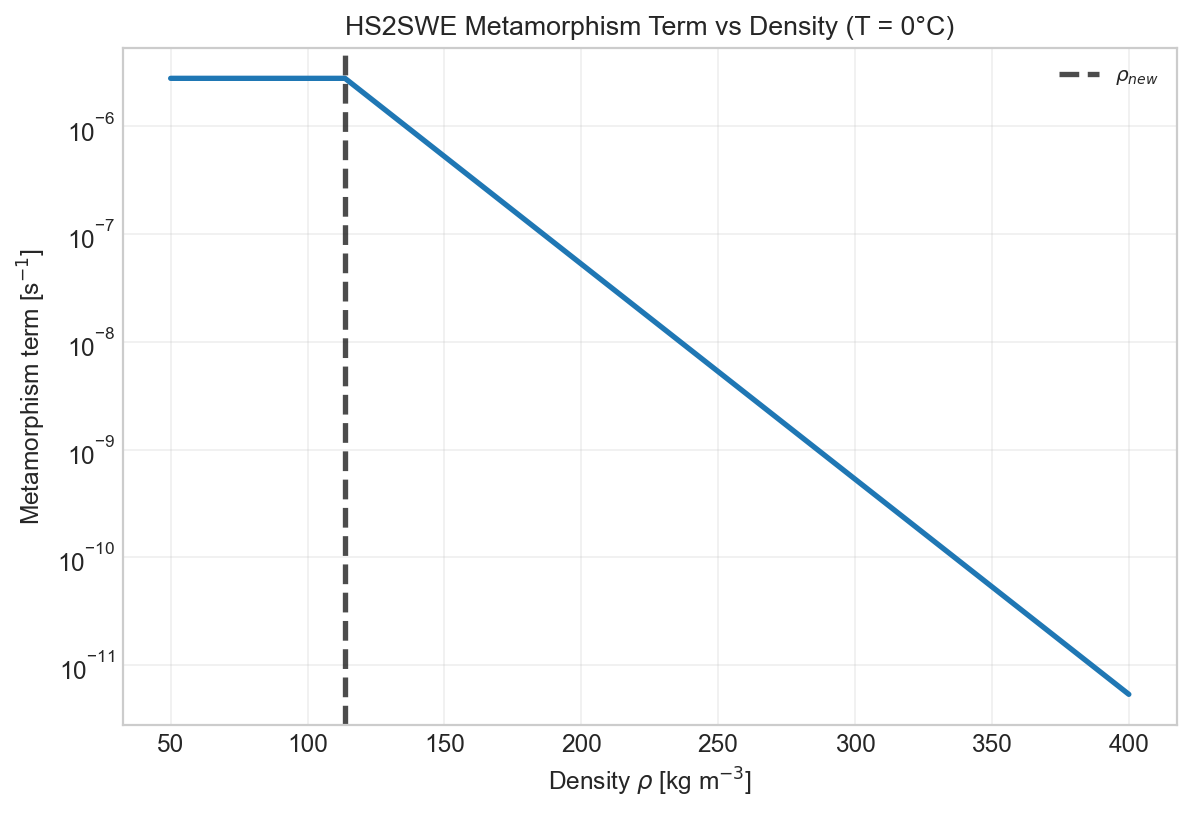

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Parameters (HS2SWE defaults)
# ============================================================
c1 = 2.8e-6
c3 = 0.046
rho_new = 113.7  # kg m^-3

# Density range
rho = np.linspace(50, 400, 600)

# ============================================================
# Metamorphism term (T = 0°C)
# ============================================================
term = c1 * np.exp(
    -c3 * np.maximum(0.0, rho - rho_new)
)

# ============================================================
# Plot styling
# ============================================================
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "lines.linewidth": 2.4,
})

fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.plot(rho, term)

# Mark rho_new
ax.axvline(rho_new, color="black", linestyle="--", alpha=0.7,
           label=r"$\rho_{new}$")

ax.set_xlabel(r"Density $\rho$ [kg m$^{-3}$]")
ax.set_ylabel("Metamorphism term [s$^{-1}$]")
ax.set_title("HS2SWE Metamorphism Term vs Density (T = 0°C)")
ax.legend()
ax.set_yscale('log')

plt.show()